In [2]:
import numpy as np
import pandas as pd
import time
from numba import njit, prange

# ============================================================
# Parámetros
# ============================================================
N = 10000
m = 2000               # grado objetivo (par)
p = 0.04
T = 50000
b = 500

EPSILONS = np.array([0.5, 0.75, 0.9], dtype=np.float64)
DELTA_FIJO = 1e-4
SIMULACIONES = 100

# Chialvo
a, q, c = 0.89, 0.18, 0.28
noise = np.random.uniform(0.026, 0.03, N)
if m % 2 != 0:
    raise ValueError("m debe ser par para WS anillo regular.")
r = m // 2


# 1) Construcción Watts–Strogatz: anillo + rewires (correcciones CSR)
def build_ws_corrections_csr(N: int, k: int, p: float, seed: int):
    """
    WS clásico: rewire aristas forward (i -> i+1..i+r) con prob p.
    Devuelve:
      removed_ptr, removed_idx: CSR removidos (respecto al anillo) por nodo
      added_ptr,   added_idx:   CSR agregados por nodo
      deg: grado final por nodo (variable)
    """
    rng = np.random.default_rng(seed)
    r = k // 2

    # Anillo: vecinos regulares
    ring_neighbors = [set() for _ in range(N)]
    for i in range(N):
        for d in range(1, r + 1):
            j = (i + d) % N
            ring_neighbors[i].add(j)
            ring_neighbors[j].add(i)

    neighbors = [set(ring_neighbors[i]) for i in range(N)]
    removed = [[] for _ in range(N)]
    added   = [[] for _ in range(N)]

    for i in range(N):
        for d in range(1, r + 1):
            j = (i + d) % N
            if rng.random() < p:
                # remover (i,j)
                if j in neighbors[i]:
                    neighbors[i].remove(j)
                    neighbors[j].remove(i)
                    removed[i].append(j)
                    removed[j].append(i)

                # elegir w nuevo (sin self-loop ni multiarista)
                while True:
                    w = int(rng.integers(0, N))
                    if w != i and (w not in neighbors[i]):
                        break

                neighbors[i].add(w)
                neighbors[w].add(i)
                added[i].append(w)
                added[w].append(i)

    deg = np.array([len(neighbors[i]) for i in range(N)], dtype=np.int32)

    def to_csr(lists):
        ptr = np.zeros(N + 1, dtype=np.int32)
        total = 0
        for i in range(N):
            total += len(lists[i])
            ptr[i + 1] = total
        idx = np.empty(total, dtype=np.int32)
        pos = 0
        for i in range(N):
            li = lists[i]
            if len(li):
                idx[pos:pos+len(li)] = np.array(li, dtype=np.int32)
            pos += len(li)
        return ptr, idx

    removed_ptr, removed_idx = to_csr(removed)
    added_ptr, added_idx = to_csr(added)

    return removed_ptr, removed_idx, added_ptr, added_idx, deg


# ============================================================
# 2) Dinámica optimizada (Numba): anillo O(N) + correcciones O(pNk)
# ============================================================
@njit(fastmath=True)
def fx_scalar(x, y, d):
    return (x * x) * np.exp(y - x) + d

@njit(fastmath=True)
def fy_scalar(x, y):
    return a * y - q * x + c

@njit(fastmath=True)
def ring_sum_prefix(fx_all, r):
    """
    Suma de vecinos del anillo:
      S_ring(i) = sum_{d=1..r} fx[i-d] + fx[i+d]
    en O(N) con prefix sums sobre vector extendido (wrap-around).
    """
    N = fx_all.shape[0]
    fx_ext = np.empty(3 * N, dtype=np.float64)
    fx_ext[0:N] = fx_all
    fx_ext[N:2*N] = fx_all
    fx_ext[2*N:3*N] = fx_all

    pref = np.empty(3 * N + 1, dtype=np.float64)
    pref[0] = 0.0
    for i in range(3 * N):
        pref[i + 1] = pref[i] + fx_ext[i]

    out = np.empty(N, dtype=np.float64)
    for i in range(N):
        center = i + N
        left  = pref[center] - pref[center - r]                  # [center-r, center-1]
        right = pref[center + r + 1] - pref[center + 1]          # [center+1, center+r]
        out[i] = left + right
    return out

@njit(parallel=True, fastmath=True)
def simulate_chialvo_ws_fast(T, b, r, removed_ptr, removed_idx, added_ptr, added_idx, deg, eps, noise):
    """
    Devuelve x_out con shape (b, N): últimos b pasos.
    Dinámica idéntica a la original: (1-eps)*f_i + eps*mean_neighbors(f_j)
    """
    N = deg.shape[0]
    x = np.random.uniform(1.0, 3.0, N)
    y = np.random.uniform(1.0, 4.0, N)
    x_out = np.zeros((b, N), dtype=np.float64)
    fx_all = np.empty(N, dtype=np.float64)
    fy_all = np.empty(N, dtype=np.float64)
    x_new  = np.empty(N, dtype=np.float64)

    for t in range(T):
        # dinámica local
        for i in prange(N):
            fx_all[i] = fx_scalar(x[i], y[i], noise[i])
            fy_all[i] = fy_scalar(x[i], y[i])

        # suma del anillo en O(N)
        ring_sums = ring_sum_prefix(fx_all, r)

        # correcciones + update
        for i in prange(N):
            s = ring_sums[i]

            # removidos del anillo
            rs = removed_ptr[i]
            re = removed_ptr[i + 1]
            for k in range(rs, re):
                j = removed_idx[k]
                s -= fx_all[j]

            # agregados por rewiring
            as_ = added_ptr[i]
            ae = added_ptr[i + 1]
            for k in range(as_, ae):
                j = added_idx[k]
                s += fx_all[j]

            ki = deg[i]
            coupling = s / ki if ki > 0 else fx_all[i]
            x_new[i] = (1.0 - eps) * fx_all[i] + eps * coupling

        y[:] = fy_all
        x[:] = x_new

        if t >= T - b:
            x_out[t - (T - b)] = x

    return x_out


# ============================================================
# 3) Conteo de clusters (Numba) SIN listas ni Counter
# ============================================================
@njit(fastmath=True)
def update_cluster_hist_from_sorted(x_sorted, delta, hist):
    """
    Dado x_sorted (ordenado), cuenta clusters donde diffs <= delta.
    Si hay una racha de L diffs pequeños, el cluster tiene tamaño L+1.
    Actualiza hist[size] += 1 (in-place).
    """
    run = 0
    n = x_sorted.shape[0]
    for i in range(n - 1):
        if x_sorted[i + 1] - x_sorted[i] <= delta:
            run += 1
        else:
            if run > 0:
                hist[run + 1] += 1
            run = 0
    if run > 0:
        hist[run + 1] += 1


# ============================================================
# 4) Loop principal: 100 redes, todos eps, guardar CSV
# ============================================================
def run_powerlaw_dataset():
    # counts[eps_idx, cluster_size]
    # cluster_size va de 0..N, usaremos 1..N (0 no se usa)
    counts = np.zeros((len(EPSILONS), N + 1), dtype=np.int64)

    # Para evitar reallocs en análisis: buffer para x_sorted
    x_sorted = np.empty(N, dtype=np.float64)

    print(f"--- INICIANDO GENERACIÓN (redes: {SIMULACIONES}, eps: {len(EPSILONS)}) ---")
    total_start = time.time()

    # (Opcional) “warmup” de compilación Numba con una red pequeña o 1 sola red
    # Aquí lo dejamos implícito: la primera iteración compila.

    for s in range(SIMULACIONES):
        seed = 1000 + s
        print(f"\nRed {s+1}/{SIMULACIONES} (seed={seed})")

        # construir red (correcciones) UNA VEZ por red
        removed_ptr, removed_idx, added_ptr, added_idx, deg = build_ws_corrections_csr(N, m, p, seed=seed)

        noise = np.random.uniform(0.026, 0.03, N).astype(np.float64)  # <- aquí

        for e_idx, eps in enumerate(EPSILONS):
            t0 = time.time()

            # correr dinámica (últimos b pasos)

            data_last = simulate_chialvo_ws_fast(T, b, r, removed_ptr, removed_idx, added_ptr, added_idx, deg, eps, noise)

            # análisis: por cada tiempo de los últimos b pasos
            hist = counts[e_idx]  # vista directa (in-place)
            for t_idx in range(b):
                # ordenar en numpy (muy rápido en C)
                x_sorted[:] = np.sort(data_last[t_idx])
                update_cluster_hist_from_sorted(x_sorted, DELTA_FIJO, hist)

            print(f"  eps={eps:.3f} listo en {time.time()-t0:.1f}s")

    print(f"\nDATA generada en {time.time()-total_start:.1f}s")
    return counts


if __name__ == "__main__":
    counts = run_powerlaw_dataset()

    # Guardado CSV tipo DataFrame:
    # filas: cluster_size, columnas: eps
    df = pd.DataFrame(
        {f"eps_{eps:.3f}": counts[i, 1:] for i, eps in enumerate(EPSILONS)},
        index=np.arange(1, N + 1)
    )
    df.index.name = "cluster_size"
    outname = "SWN_Heterogeneity_data_2.csv"
    df.to_csv(outname)
    print(f"\n¡Guardado exitoso en '{outname}'!")


--- INICIANDO GENERACIÓN (redes: 100, eps: 3) ---

Red 1/100 (seed=1000)
  eps=0.500 listo en 18.8s
  eps=0.750 listo en 16.5s
  eps=0.900 listo en 15.3s

Red 2/100 (seed=1001)
  eps=0.500 listo en 16.5s
  eps=0.750 listo en 17.5s
  eps=0.900 listo en 18.2s

Red 3/100 (seed=1002)
  eps=0.500 listo en 16.2s
  eps=0.750 listo en 21.8s
  eps=0.900 listo en 18.2s

Red 4/100 (seed=1003)
  eps=0.500 listo en 15.9s
  eps=0.750 listo en 17.3s
  eps=0.900 listo en 18.9s

Red 5/100 (seed=1004)
  eps=0.500 listo en 16.0s
  eps=0.750 listo en 19.4s
  eps=0.900 listo en 17.1s

Red 6/100 (seed=1005)
  eps=0.500 listo en 18.4s
  eps=0.750 listo en 20.8s
  eps=0.900 listo en 22.0s

Red 7/100 (seed=1006)
  eps=0.500 listo en 16.1s
  eps=0.750 listo en 22.0s
  eps=0.900 listo en 17.3s

Red 8/100 (seed=1007)
  eps=0.500 listo en 15.8s
  eps=0.750 listo en 17.7s
  eps=0.900 listo en 21.6s

Red 9/100 (seed=1008)
  eps=0.500 listo en 15.8s
  eps=0.750 listo en 21.5s
  eps=0.900 listo en 17.0s

Red 10/100 (s

['eps_0.500', 'eps_0.750', 'eps_0.900']


C:\Users\juanc\AppData\Local\Temp\ipykernel_27996\4254943945.py:104: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 10000 - 500)


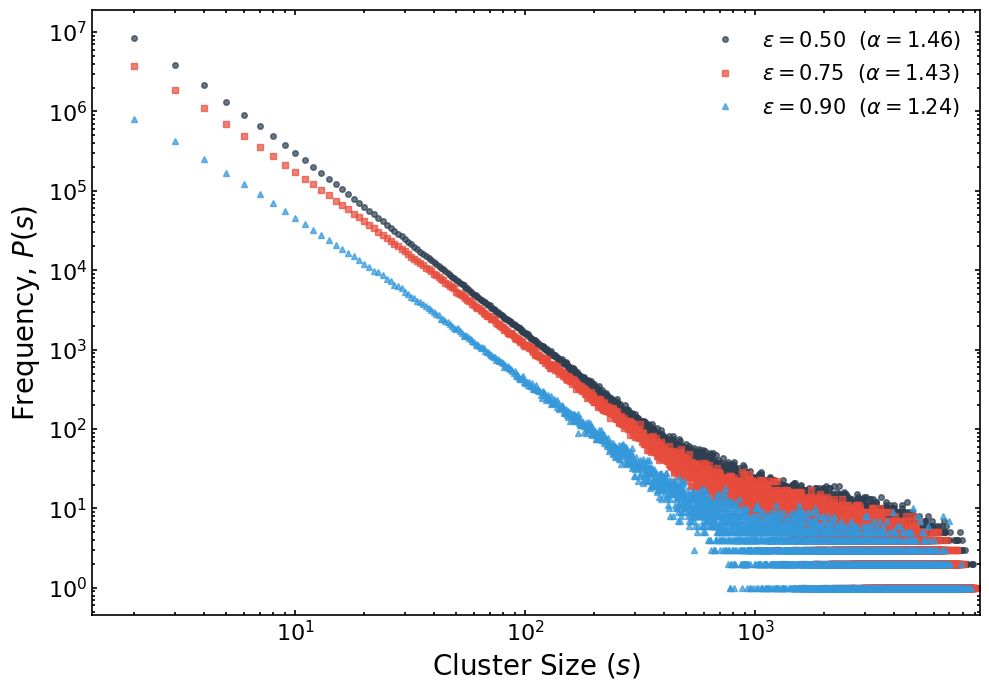

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Si no quieres depender de scipy, uso np.polyfit para el fit log-log.
# (Si prefieres scipy.stats.linregress te lo adapto también.)
def get_power_law_alpha(x, y, x_min, x_max):
    """Fit en log-log: log10(y) = slope*log10(x) + c  => alpha = -slope"""
    mask = (x >= x_min) & (x <= x_max) & (y > 0)
    x_fit = x[mask]
    y_fit = y[mask]
    if len(x_fit) < 2:
        return np.nan, np.nan

    lx = np.log10(x_fit)
    ly = np.log10(y_fit)

    slope, intercept = np.polyfit(lx, ly, 1)

    # R^2
    #yhat = slope * lx + intercept
    #ss_res = np.sum((ly - yhat)**2)
    #ss_tot = np.sum((ly - np.mean(ly))**2)
    #r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    alpha = -slope
    return alpha


# ----------------------------
# 1) CARGAR DATA
# ----------------------------
fname = "SWN_Heterogeneity_data_2.csv"
df = pd.read_csv(fname, index_col="cluster_size")

# Asegurar que el índice sea numérico e incremental
df.index = df.index.astype(int)
df = df.sort_index()

# ----------------------------
# 2) CONFIG
# ----------------------------
FLOOR = 1

FIT_MIN = 10
FIT_MAX = 10000

NORMALIZE = False

eps_cols = [
    c for c in df.columns
    if c.startswith("eps_") and c != "eps_1.000"
]
# Opción B: fija manual (descomenta si quieres)
# eps_cols = ["eps_0.350", "eps_0.400", "eps_0.500", "eps_0.600"]
print(eps_cols)
# Colores / marcadores (pon los que quieras)
colors = {0.5: '#2c3e50', 0.75: '#e74c3c', 0.9: '#3498db'} 
markers = {0.5: 'o', 0.75: 's', 0.9: '^'} 

# ----------------------------
# 3) PLOT
# ----------------------------
plt.figure(figsize=(10, 7))

x_val = df.index.values.astype(float)

for col in eps_cols:
    # col = "eps_0.350" -> eps = 0.35
    eps = float(col.replace("eps_", ""))

    y_val = df[col].values.astype(float)

    if NORMALIZE:
        tot = np.sum(y_val)
        if tot > 0:
            y_val = y_val / tot

    # floor para plot
    mask_floor = y_val >= FLOOR
    x_plot = x_val[mask_floor]
    y_plot = y_val[mask_floor]
    if len(x_plot) == 0:
        continue

    alpha = get_power_law_alpha(x_val, y_val, FIT_MIN, FIT_MAX)

    label_txt = (
        fr"$\epsilon={eps:.2f}$  "
        + (fr"($\alpha={alpha:.2f}$)" if np.isfinite(alpha) else "[fit n/a]")
    )

    plt.loglog(
        x_plot, y_plot,
        linestyle="none",
        marker=markers.get(eps, "o"),
        markersize=4,
        color=colors.get(eps, "k"),
        alpha=0.7,
        label=label_txt
    )

# Estética estilo “Kaneko-ish”
plt.xlim(0, 10000 - 500)
plt.xlabel(r'Cluster Size ($s$)', fontsize=20)
plt.ylabel(r'Frequency, $P(s)$', fontsize=20)

legend = plt.legend(fontsize=15, frameon=False, fancybox=False, edgecolor='black', loc='upper right')
legend.get_frame().set_linewidth(1.0)

plt.grid(False)
ax = plt.gca()
for side in ["top", "right", "bottom", "left"]:
    ax.spines[side].set_linewidth(1.2)
ax.tick_params(width=1.2, which='both',labelsize=16, direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


Hacer de nuevo con 0.5, 0.75, 0.8, 0.9

['eps_0.500', 'eps_0.750', 'eps_0.900']


C:\Users\juanc\AppData\Local\Temp\ipykernel_19216\1797759393.py:101: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 10000 - 500)


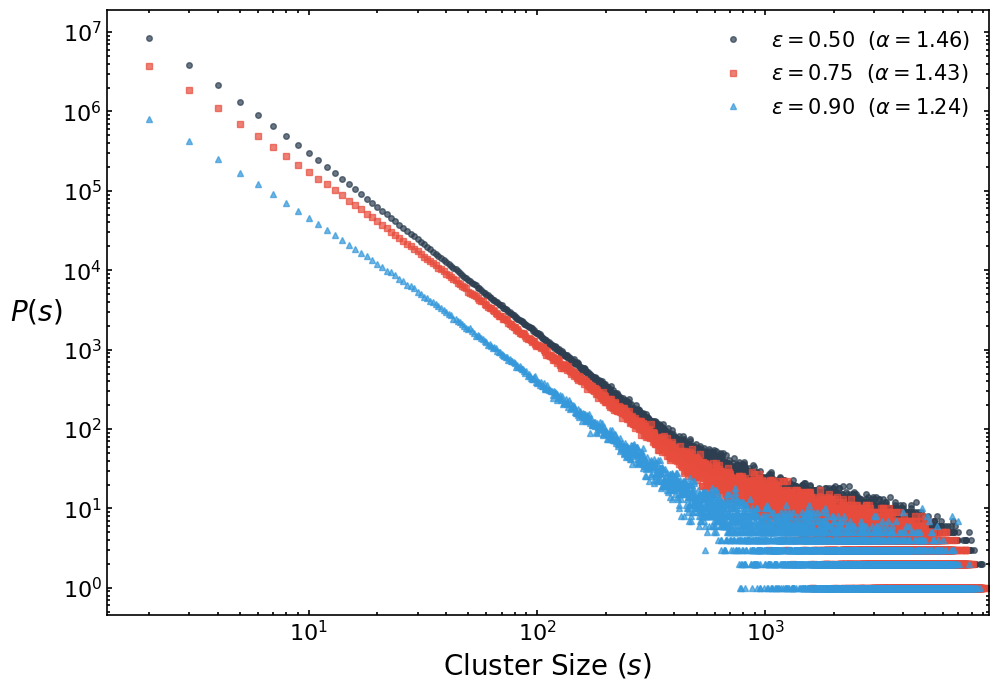

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Si no quieres depender de scipy, uso np.polyfit para el fit log-log.
# (Si prefieres scipy.stats.linregress te lo adapto también.)
def get_power_law_alpha(x, y, x_min, x_max):
    """Fit en log-log: log10(y) = slope*log10(x) + c  => alpha = -slope"""
    mask = (x >= x_min) & (x <= x_max) & (y > 0)
    x_fit = x[mask]
    y_fit = y[mask]
    if len(x_fit) < 2:
        return np.nan, np.nan

    lx = np.log10(x_fit)
    ly = np.log10(y_fit)

    slope, intercept = np.polyfit(lx, ly, 1)

    # R^2
    #yhat = slope * lx + intercept
    #ss_res = np.sum((ly - yhat)**2)
    #ss_tot = np.sum((ly - np.mean(ly))**2)
    #r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    alpha = -slope
    return alpha
# ----------------------------
# 1) CARGAR DATA
# ----------------------------
fname = "SWN_Heterogeneity_data_2.csv"
df = pd.read_csv(fname, index_col="cluster_size")

# Asegurar que el índice sea numérico e incremental
df.index = df.index.astype(int)
df = df.sort_index()

# ----------------------------
# 2) CONFIG
# ----------------------------
FLOOR = 1

FIT_MIN = 10
FIT_MAX = 10000

NORMALIZE = False

eps_cols = [
    c for c in df.columns
    if c.startswith("eps_") and c != "eps_1.000"
]
# Opción B: fija manual (descomenta si quieres)
# eps_cols = ["eps_0.350", "eps_0.400", "eps_0.500", "eps_0.600"]
print(eps_cols)
# Colores / marcadores (pon los que quieras)
colors = {0.5: '#2c3e50', 0.75: '#e74c3c', 0.9: '#3498db'} 
markers = {0.5: 'o', 0.75: 's', 0.9: '^'} 

# ----------------------------
# 3) PLOT
# ----------------------------
plt.figure(figsize=(10, 7))

x_val = df.index.values.astype(float)

for col in eps_cols:
    # col = "eps_0.350" -> eps = 0.35
    eps = float(col.replace("eps_", ""))

    y_val = df[col].values.astype(float)

    if NORMALIZE:
        tot = np.sum(y_val)
        if tot > 0:
            y_val = y_val / tot

    # floor para plot
    mask_floor = y_val >= FLOOR
    x_plot = x_val[mask_floor]
    y_plot = y_val[mask_floor]
    if len(x_plot) == 0:
        continue

    alpha = get_power_law_alpha(x_val, y_val, FIT_MIN, FIT_MAX)

    label_txt = (
        fr"$\epsilon={eps:.2f}$  "
        + (fr"($\alpha={alpha:.2f}$)" if np.isfinite(alpha) else "[fit n/a]")
    )

    plt.loglog(
        x_plot, y_plot,
        linestyle="none",
        marker=markers.get(eps, "o"),
        markersize=4,
        color=colors.get(eps, "k"),
        alpha=0.7,
        label=label_txt
    )

plt.xlim(0, 10000 - 500)
plt.xlabel(r'Cluster Size ($s$)', fontsize=20)
plt.ylabel(r'$P(s)$', fontsize=20, rotation=0)

legend = plt.legend(fontsize=15, frameon=False, fancybox=False, edgecolor='black', loc='upper right')
legend.get_frame().set_linewidth(1.0)

plt.grid(False)
ax = plt.gca()
for side in ["top", "right", "bottom", "left"]:
    ax.spines[side].set_linewidth(1.2)
ax.tick_params(width=1.2, which='both',labelsize=16, direction='in', top=True, right=True)
ax.yaxis.set_label_coords(-0.08, 0.478)

filename = 'Fig7_Power_Law.pdf'
plt.savefig(filename, format='pdf', dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()
